In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
#  add light grid to adll figs
plt.rcParams.update({
        "text.usetex": False,          # disable system LaTeX
        "mathtext.fontset": "stix",    # nicer math font
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "grid.color": "lightgray",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
    })

In [4]:
def concat_results(base_dir, mode, suffix_present=True):
    df_list = []
    # 20, 30, 40, 50, 60, 70, 80, 90,
    suffix=""
    if (mode == "NProbe" and suffix_present):
        # print("nprobe")
        suffix="_with_oracle"

    for t in [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
        df = pd.read_csv(f"{base_dir}/full_results_{mode}_t{t}{suffix}.csv")
        df["t"] = t
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

In [5]:
# theoretical recall @ 10 vs step
# on SIFT/MSTuring Static sets
# surge & gp-ann
# TODO: compute real imbalance information for all

In [6]:
# gp-ann to generate: (also computes real recall, runs in distributed setting)
# 1. python extract_first_batch.py
# 2. ./Partition - partitions on first batch
# 3. mv partitions ->partitions.local (only for shift?)
# 3. offset_partition.py partitions.local -> partitions (only for shift?)
# 2. ./DistributedInsertBenchSweep

# surge - to generate:
# 1. ./bin/msturing-cluster-analysis
# 2. ./bin/runbook_partitions_parallel
# 3. python compute_theoretical_recall_updated.py


# /dataset/surge/results/runbook_theoretical_runs/bigann-clustered/full_results_sweep_t0.csv
# /dataset/gp-ann-inserts/results/msturing100Mclustered_runbook_results_nprobe5.csv

In [7]:
# runbook phases for plotting
# step 0-128: insert
# step 128-256: delete
# step 256-384: insert
# step 384-512: delete
# step 512-640: insert
# step 640-768: delete
# step 768-896: insert
# step 896-1024: delete
# step 1024-1152: insert
# step 1152-1280: delete

# shift runbook phases:
# step 0-208: insert
# step 208-245: delete
# step 235-338: insert
# step 338-364: delete
# step 365-468: insert
# step 468-494: delete
# step 495-590: insert
# step 591-616: delete

In [8]:
no_rebuilds_color = "firebrick"
no_rebuilds_label = "no maintenance"

rebuilds_color = "C0"
rebuilds_label = "with maintenance"

In [9]:
shard_cols = ["shard_0_active","shard_1_active","shard_2_active",
              "shard_3_active","shard_4_active","shard_5_active",
              "shard_6_active","shard_7_active","shard_8_active","shard_9_active"]


def gini(counts):
    arr = np.sort(np.array(counts, dtype=float))
    n = len(arr)
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * arr) / (n * np.sum(arr))) - (n + 1) / n

In [10]:
# bigann_clustered_path = "/dataset/big-ann-benchmarks/data/bigann-clustered/cluster_history_bigann-100M-clustered_10000_10/full_results_RecallTarget.csv"
# bigann_clustered = pd.read_csv(bigann_clustered_path)
bigann_clustered_path = "/dataset/big-ann-benchmarks/data/bigann-clustered/cluster_history_bigann-100M-clustered_10000_10"
bigann_clustered_recalltarget = concat_results(bigann_clustered_path, "RecallTarget")
bigann_clustered_bf = concat_results(bigann_clustered_path, "BranchingFactor")
bigann_clustered_nprobe = concat_results(bigann_clustered_path, "NProbe")

# concatenate all bigann clustered results into one dataframe
bigann_clustered = pd.concat([bigann_clustered_recalltarget, bigann_clustered_bf, bigann_clustered_nprobe], axis=0)

gpann_bigann_clustered = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-clustered/gpann_partitions/bigann100Mclustered_runbook_results_nprobe_with_theo_sweep.csv")
gpann_bigann_clustered["gini"] = gpann_bigann_clustered[shard_cols].apply(lambda row: gini(row.values), axis=1)

bigann_clustered_imbalance_df_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-clustered/cluster_history_bigann-100M-clustered_10000_10/full_real_imbalance_no_rebuilding_results.csv")
bigann_clustered_imbalance_df_t0 = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-clustered/cluster_history_bigann-100M-clustered_10000_10/full_real_imbalance_rebuilding_results.csv")

bigann_clustered_imbalance_t0 = []
for step, group in bigann_clustered_imbalance_df_t0.groupby("stepNum"):
    # print(gini(group["count"]))
    bigann_clustered_imbalance_t0.append(gini(group["count"]))

bigann_clustered_imbalance_t100 = []
for step, group in bigann_clustered_imbalance_df_t100.groupby("stepNum"):
    # print(gini(group["count"]))
    bigann_clustered_imbalance_t100.append(gini(group["count"]))

In [11]:
bigann_random_path = "/dataset/big-ann-benchmarks/data/bigann-random/cluster_history_bigann-100M-random_10000_10"
bigann_random_recalltarget = concat_results(bigann_random_path, "RecallTarget")
bigann_random_bf = concat_results(bigann_random_path, "BranchingFactor")
bigann_random_nprobe = concat_results(bigann_random_path, "NProbe")

bigann_random = pd.concat([bigann_random_recalltarget, bigann_random_bf, bigann_random_nprobe], axis=0)

gpann_bigann_random = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-random/gpann_partitions/bigann100Mrandom_runbook_results_nprobe_with_theo_sweep.csv")
gpann_bigann_random["gini"] = gpann_bigann_random[shard_cols].apply(lambda row: gini(row.values), axis=1)

bigann_random_imbalance_df_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-random/cluster_history_bigann-100M-random_10000_10/full_real_imbalance_no_rebuilding_results.csv")
bigann_random_imbalance_df_t0 = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-random/cluster_history_bigann-100M-random_10000_10/full_real_imbalance_rebuilding_results.csv")

bigann_random_imbalance_t0 = []
for step, group in bigann_random_imbalance_df_t0.groupby("stepNum"):
    # print(gini(group["count"]))
    bigann_random_imbalance_t0.append(gini(group["count"]))

bigann_random_imbalance_t100 = []
for step, group in bigann_random_imbalance_df_t100.groupby("stepNum"):
    # print(gini(group["count"]))
    bigann_random_imbalance_t100.append(gini(group["count"]))

In [12]:
bigann_shift_path = "/dataset/big-ann-benchmarks/data/bigann-shift/cluster_history_bigann-100M-shift_10000_10"
bigann_shift_recalltarget = concat_results(bigann_shift_path, "RecallTarget")
bigann_shift_bf = concat_results(bigann_shift_path, "BranchingFactor")
bigann_shift_nprobe = concat_results(bigann_shift_path, "NProbe", False)

bigann_shift = pd.concat([bigann_shift_recalltarget, bigann_shift_bf, bigann_shift_nprobe], axis=0)

gpann_bigann_shift = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-shift/gpann_partitions/bigann100Mshift_runbook_results_nprobe_with_theo_sweep.csv")
gpann_bigann_shift["gini"] = gpann_bigann_shift[shard_cols].apply(lambda row: gini(row.values), axis=1)


bigann_shift_imbalance_df_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-shift/cluster_history_bigann-100M-shift_10000_10/full_real_imbalance_no_rebuilding_results.csv")
bigann_shift_imbalance_df_t0 = pd.read_csv("/dataset/big-ann-benchmarks/data/bigann-shift/cluster_history_bigann-100M-shift_10000_10/full_real_imbalance_rebuilding_results.csv")

bigann_shift_imbalance_t0 = []
for step, group in bigann_shift_imbalance_df_t0.groupby("stepNum"):
    # print(gini(group["count"]))
    bigann_shift_imbalance_t0.append(gini(group["count"]))

bigann_shift_imbalance_t100 = []
for step, group in bigann_shift_imbalance_df_t100.groupby("stepNum"):
    # print(gini(group["count"]))
    bigann_shift_imbalance_t100.append(gini(group["count"]))

In [13]:
msturing_random_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-random/cluster_history_msturing-100M-random_10000_10"
msturing_random_recalltarget = concat_results(msturing_random_path, "RecallTarget")
msturing_random_bf = concat_results(msturing_random_path, "BranchingFactor")
msturing_random_nprobe = concat_results(msturing_random_path, "NProbe")

msturing_random = pd.concat([msturing_random_recalltarget, msturing_random_bf, msturing_random_nprobe], axis=0)

# but gpann reports real recall
gpann_msturing_random = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-random/gpann_partitions/msturing100Mrandom_runbook_results_nprobe_with_theo_sweep.csv")
gpann_msturing_random["gini"] = gpann_msturing_random[shard_cols].apply(lambda row: gini(row.values), axis=1)

msturing_random_imbalance_df_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-random/cluster_history_msturing-100M-random_10000_10/full_real_imbalance_no_rebuilding_results.csv")
msturing_random_imbalance_df_t0 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-random/cluster_history_msturing-100M-random_10000_10/full_real_imbalance_rebuilding_results.csv")

msturing_random_imbalance_t0 = []
for step, group in msturing_random_imbalance_df_t0.groupby("stepNum"):
    # print(gini(group["count"]))
    msturing_random_imbalance_t0.append(gini(group["count"]))

msturing_random_imbalance_t100 = []
for step, group in msturing_random_imbalance_df_t100.groupby("stepNum"):
    # print(gini(group["count"]))
    msturing_random_imbalance_t100.append(gini(group["count"]))

In [14]:
msturing_clustered_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/cluster_history_msturing-100M-clustered_10000_10"
msturing_clustered_recalltarget = concat_results(msturing_clustered_path, "RecallTarget")
msturing_clustered_bf = concat_results(msturing_clustered_path, "BranchingFactor")
msturing_clustered_nprobe = concat_results(msturing_clustered_path, "NProbe")

msturing_clustered = pd.concat([msturing_clustered_recalltarget, msturing_clustered_bf, msturing_clustered_nprobe], axis=0)

gpann_msturing_clustered = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/gpann_partitions/msturing100Mclustered_runbook_results_nprobe_with_theo_sweep.csv")
gpann_msturing_clustered["gini"] = gpann_msturing_clustered[shard_cols].apply(lambda row: gini(row.values), axis=1)


msturing_clustered_imbalance_df_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/cluster_history_msturing-100M-clustered_10000_10/full_real_imbalance_no_rebuilding_results.csv")
msturing_clustered_imbalance_df_t0 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-clustered/cluster_history_msturing-100M-clustered_10000_10/full_real_imbalance_rebuilding_results.csv")

msturing_clustered_imbalance_t0 = []
for step, group in msturing_clustered_imbalance_df_t0.groupby("stepNum"):
    # print(gini(group["count"]))
    msturing_clustered_imbalance_t0.append(gini(group["count"]))

msturing_clustered_imbalance_t100 = []
for step, group in msturing_clustered_imbalance_df_t100.groupby("stepNum"):
    # print(gini(group["count"]))
    msturing_clustered_imbalance_t100.append(gini(group["count"]))

In [ ]:
msturing_shift_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/cluster_history_msturing-100M-shift_10000_10"
msturing_shift_weighted_path = "/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/cluster_history_msturing-100M-shift_10000_10_nodeweighted/"

msturing_shift_recalltarget = concat_results(msturing_shift_path, "RecallTarget")
msturing_shift_bf = concat_results(msturing_shift_path, "BranchingFactor")
msturing_shift_nprobe = concat_results(msturing_shift_path, "NProbe")

# msturing_shift_weighted_recalltarget = concat_results(msturing_shift_weighted_path, "RecallTarget")

msturing_shift = pd.concat([msturing_shift_recalltarget, msturing_shift_bf, msturing_shift_nprobe], axis=0)
# msturing_shift_weighted = pd.concat([msturing_shift_weighted_recalltarget], axis=0)

gpann_msturing_shift = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/gpann_partitions/msturing100Mshift_runbook_results_nprobe_with_theo_sweep.csv")
gpann_msturing_shift["gini"] = gpann_msturing_shift[shard_cols].apply(lambda row: gini(row.values), axis=1)

msturing_shift_imbalance_df_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/cluster_history_msturing-100M-shift_10000_10/full_real_imbalance_no_rebuilding_results.csv")
msturing_shift_imbalance_df_t0 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/cluster_history_msturing-100M-shift_10000_10/full_real_imbalance_rebuilding_results.csv")

msturing_shift_imbalance_t0 = []
for step, group in msturing_shift_imbalance_df_t0.groupby("stepNum"):
    # print(gini(group["count"]))
    msturing_shift_imbalance_t0.append(gini(group["count"]))

msturing_shift_imbalance_t100 = []
for step, group in msturing_shift_imbalance_df_t100.groupby("stepNum"):
    # print(gini(group["count"]))
    msturing_shift_imbalance_t100.append(gini(group["count"]))

# Thresholds

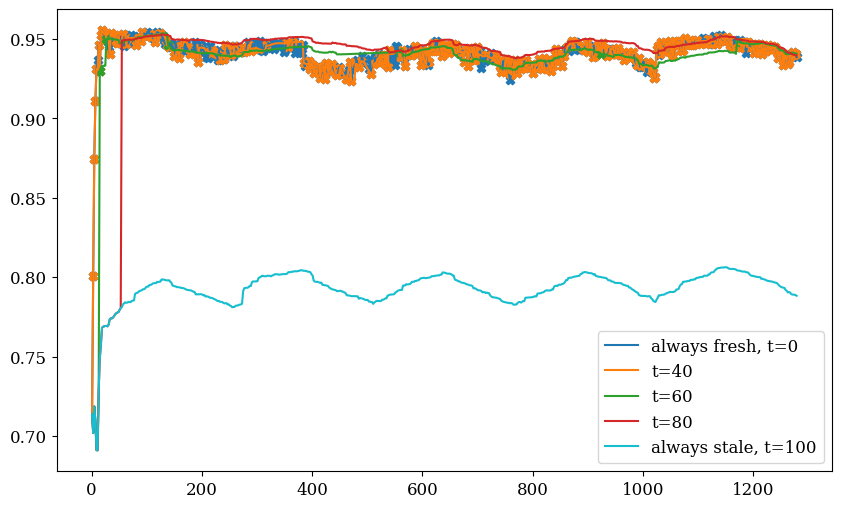

In [29]:
mode = "NProbe"
param = 5

colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']

dataset = msturing_clustered

t=0
plt.figure(figsize=(10, 6))
plt.plot(
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["step"],
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["recall"],
    label=f"always fresh, t={t}", color=colors[0]
)
plt.scatter(dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["step"],
            dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["recall"],
            # label="t=0",
            marker="X", color=colors[0]
            )

# set size
for i, t in enumerate([40, 60, 80], 1):
    # plt.figure(figsize=(10, 6))
    plt.plot(
        dataset[(dataset["t"] == t) &
                    (dataset['mode'] == mode) &
                    (dataset["param"] == param)
                    ]["step"],
        dataset[(dataset["t"] == t) &
                    (dataset['mode'] == mode) &
                    (dataset["param"] == param)
                    ]["recall"],
        label=f"t={t}", color = colors[i]
    )
    plt.scatter(dataset[(dataset["t"] == t) &
                    (dataset["param"] == param) &
                    (dataset['mode'] == mode) &
                    (dataset["did_rebuild"] == True)
                    ]["step"],
                dataset[(dataset["t"] == t) &
                    (dataset["param"] == param) &
                    (dataset['mode'] == mode) &
                    (dataset["did_rebuild"] == True)
                    ]["recall"],
                # label="t=0",
                marker="X", color=colors[i]
                )

t=100
# plt.figure(figsize=(10, 6))
plt.plot(
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["step"],
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["recall"],
    label=f"always stale, t={t}", color=colors[-1]
)
plt.scatter(dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["step"],
            dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["recall"],
            # label="t=0",
            marker="X", color=colors[-1]
            )

plt.legend()


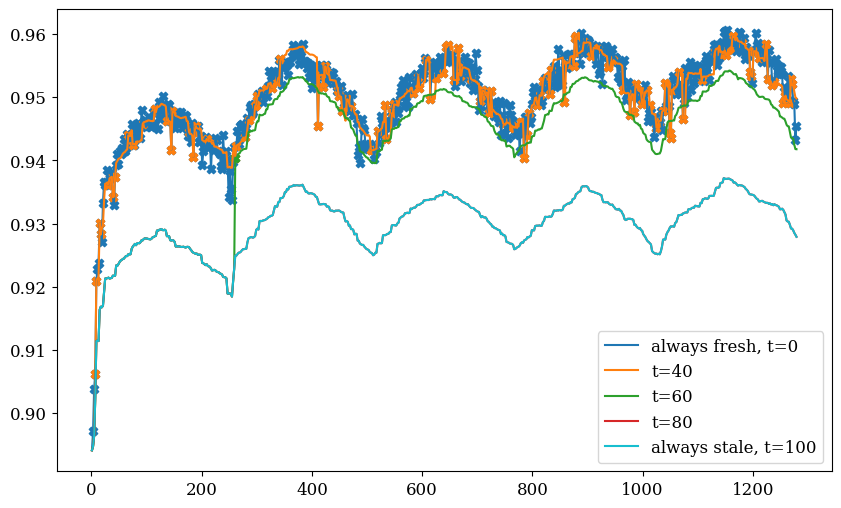

In [31]:
mode = "NProbe"
param = 5

colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']

dataset = msturing_random

t=0
plt.figure(figsize=(10, 6))
plt.plot(
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["step"],
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["recall"],
    label=f"always fresh, t={t}", color=colors[0]
)
plt.scatter(dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["step"],
            dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["recall"],
            # label="t=0",
            marker="X", color=colors[0]
            )

# set size
for i, t in enumerate([40, 60, 80], 1):
    # plt.figure(figsize=(10, 6))
    plt.plot(
        dataset[(dataset["t"] == t) &
                    (dataset['mode'] == mode) &
                    (dataset["param"] == param)
                    ]["step"],
        dataset[(dataset["t"] == t) &
                    (dataset['mode'] == mode) &
                    (dataset["param"] == param)
                    ]["recall"],
        label=f"t={t}", color = colors[i]
    )
    plt.scatter(dataset[(dataset["t"] == t) &
                    (dataset["param"] == param) &
                    (dataset['mode'] == mode) &
                    (dataset["did_rebuild"] == True)
                    ]["step"],
                dataset[(dataset["t"] == t) &
                    (dataset["param"] == param) &
                    (dataset['mode'] == mode) &
                    (dataset["did_rebuild"] == True)
                    ]["recall"],
                # label="t=0",
                marker="X", color=colors[i]
                )

t=100
# plt.figure(figsize=(10, 6))
plt.plot(
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["step"],
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["recall"],
    label=f"always stale, t={t}", color=colors[-1]
)
plt.scatter(dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["step"],
            dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["recall"],
            # label="t=0",
            marker="X", color=colors[-1]
            )

plt.legend()

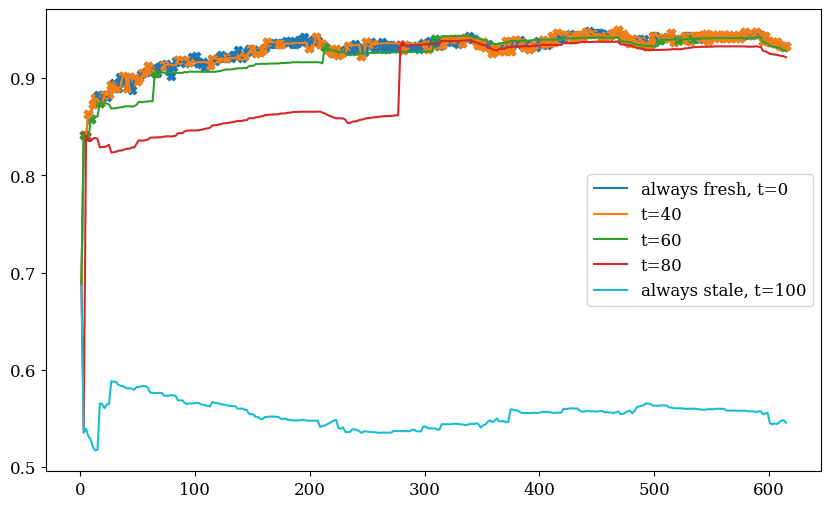

In [28]:
mode = "NProbe"
param = 5

colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']

dataset = msturing_shift

t=0
plt.figure(figsize=(10, 6))
plt.plot(
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["step"],
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["recall"],
    label=f"always fresh, t={t}", color=colors[0]
)
plt.scatter(dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["step"],
            dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["recall"],
            # label="t=0",
            marker="X", color=colors[0]
            )

# set size
for i, t in enumerate([40, 60, 80], 1):
    # plt.figure(figsize=(10, 6))
    plt.plot(
        dataset[(dataset["t"] == t) &
                    (dataset['mode'] == mode) &
                    (dataset["param"] == param)
                    ]["step"],
        dataset[(dataset["t"] == t) &
                    (dataset['mode'] == mode) &
                    (dataset["param"] == param)
                    ]["recall"],
        label=f"t={t}", color = colors[i]
    )
    plt.scatter(dataset[(dataset["t"] == t) &
                    (dataset["param"] == param) &
                    (dataset['mode'] == mode) &
                    (dataset["did_rebuild"] == True)
                    ]["step"],
                dataset[(dataset["t"] == t) &
                    (dataset["param"] == param) &
                    (dataset['mode'] == mode) &
                    (dataset["did_rebuild"] == True)
                    ]["recall"],
                # label="t=0",
                marker="X", color=colors[i]
                )

t=100
# plt.figure(figsize=(10, 6))
plt.plot(
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["step"],
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["recall"],
    label=f"always stale, t={t}", color=colors[-1]
)
plt.scatter(dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["step"],
            dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["recall"],
            # label="t=0",
            marker="X", color=colors[-1]
            )

plt.legend()

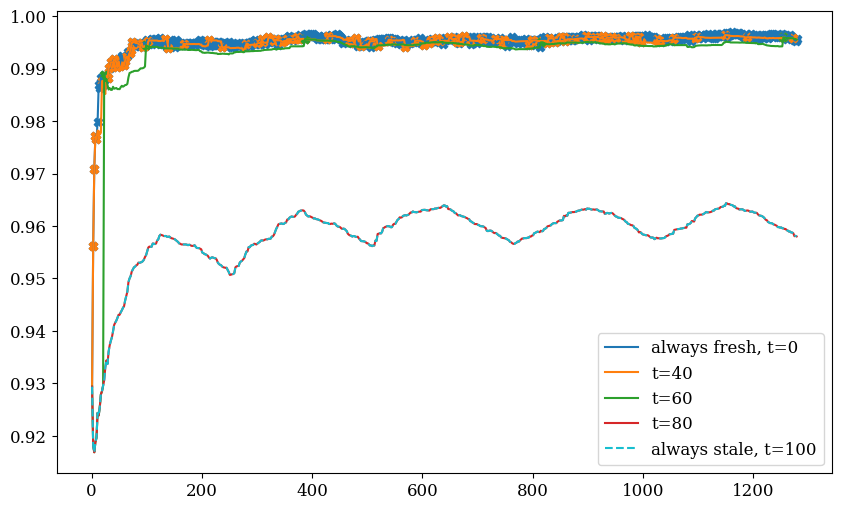

In [34]:
mode = "NProbe"
param = 5

colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']

dataset = bigann_clustered

t=0
plt.figure(figsize=(10, 6))
plt.plot(
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["step"],
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["recall"],
    label=f"always fresh, t={t}", color=colors[0]
)
plt.scatter(dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["step"],
            dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["recall"],
            # label="t=0",
            marker="X", color=colors[0]
            )

# set size
for i, t in enumerate([40, 60, 80], 1):
    # plt.figure(figsize=(10, 6))
    plt.plot(
        dataset[(dataset["t"] == t) &
                    (dataset['mode'] == mode) &
                    (dataset["param"] == param)
                    ]["step"],
        dataset[(dataset["t"] == t) &
                    (dataset['mode'] == mode) &
                    (dataset["param"] == param)
                    ]["recall"],
        label=f"t={t}", color = colors[i]
    )
    plt.scatter(dataset[(dataset["t"] == t) &
                    (dataset["param"] == param) &
                    (dataset['mode'] == mode) &
                    (dataset["did_rebuild"] == True)
                    ]["step"],
                dataset[(dataset["t"] == t) &
                    (dataset["param"] == param) &
                    (dataset['mode'] == mode) &
                    (dataset["did_rebuild"] == True)
                    ]["recall"],
                # label="t=0",
                marker="X", color=colors[i]
                )

t=100
# plt.figure(figsize=(10, 6))
plt.plot(
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["step"],
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["recall"],
    label=f"always stale, t={t}", color=colors[-1], ls="--"
)
plt.scatter(dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["step"],
            dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["recall"],
            # label="t=0",
            marker="X", color=colors[-1]
            )

plt.legend()

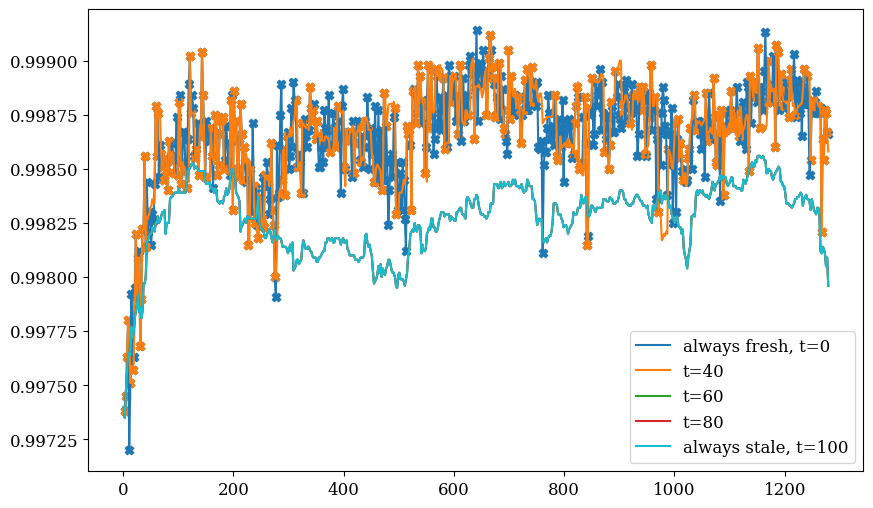

In [35]:
mode = "NProbe"
param = 5

colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']

dataset = bigann_random

t=0
plt.figure(figsize=(10, 6))
plt.plot(
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["step"],
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["recall"],
    label=f"always fresh, t={t}", color=colors[0]
)
plt.scatter(dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["step"],
            dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["recall"],
            # label="t=0",
            marker="X", color=colors[0]
            )

# set size
for i, t in enumerate([40, 60, 80], 1):
    # plt.figure(figsize=(10, 6))
    plt.plot(
        dataset[(dataset["t"] == t) &
                    (dataset['mode'] == mode) &
                    (dataset["param"] == param)
                    ]["step"],
        dataset[(dataset["t"] == t) &
                    (dataset['mode'] == mode) &
                    (dataset["param"] == param)
                    ]["recall"],
        label=f"t={t}", color = colors[i]
    )
    plt.scatter(dataset[(dataset["t"] == t) &
                    (dataset["param"] == param) &
                    (dataset['mode'] == mode) &
                    (dataset["did_rebuild"] == True)
                    ]["step"],
                dataset[(dataset["t"] == t) &
                    (dataset["param"] == param) &
                    (dataset['mode'] == mode) &
                    (dataset["did_rebuild"] == True)
                    ]["recall"],
                # label="t=0",
                marker="X", color=colors[i]
                )

t=100
# plt.figure(figsize=(10, 6))
plt.plot(
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["step"],
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["recall"],
    label=f"always stale, t={t}", color=colors[-1]
)
plt.scatter(dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["step"],
            dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["recall"],
            # label="t=0",
            marker="X", color=colors[-1]
            )

plt.legend()

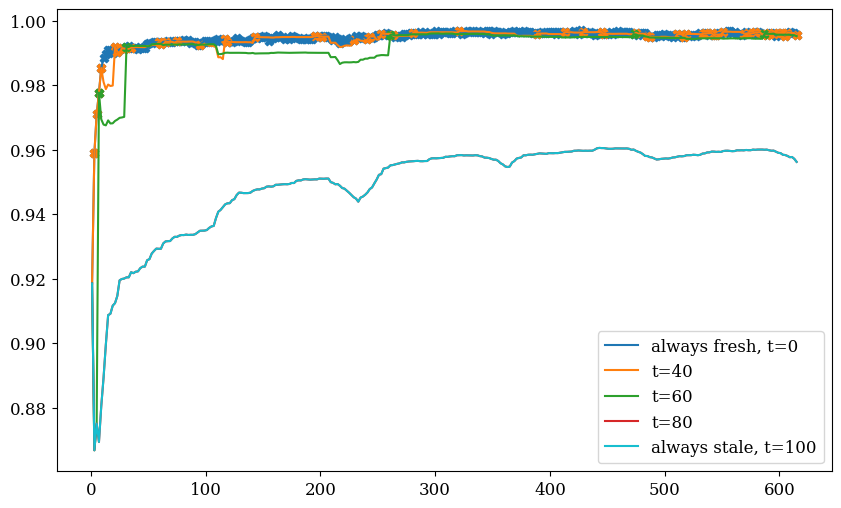

In [36]:
mode = "NProbe"
param = 5

colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']

dataset = bigann_shift

t=0
plt.figure(figsize=(10, 6))
plt.plot(
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["step"],
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["recall"],
    label=f"always fresh, t={t}", color=colors[0]
)
plt.scatter(dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["step"],
            dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["recall"],
            # label="t=0",
            marker="X", color=colors[0]
            )

# set size
for i, t in enumerate([40, 60, 80], 1):
    # plt.figure(figsize=(10, 6))
    plt.plot(
        dataset[(dataset["t"] == t) &
                    (dataset['mode'] == mode) &
                    (dataset["param"] == param)
                    ]["step"],
        dataset[(dataset["t"] == t) &
                    (dataset['mode'] == mode) &
                    (dataset["param"] == param)
                    ]["recall"],
        label=f"t={t}", color = colors[i]
    )
    plt.scatter(dataset[(dataset["t"] == t) &
                    (dataset["param"] == param) &
                    (dataset['mode'] == mode) &
                    (dataset["did_rebuild"] == True)
                    ]["step"],
                dataset[(dataset["t"] == t) &
                    (dataset["param"] == param) &
                    (dataset['mode'] == mode) &
                    (dataset["did_rebuild"] == True)
                    ]["recall"],
                # label="t=0",
                marker="X", color=colors[i]
                )

t=100
# plt.figure(figsize=(10, 6))
plt.plot(
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["step"],
    dataset[(dataset["t"] == t) &
                (dataset['mode'] == mode) &
                (dataset["param"] == param)
                ]["recall"],
    label=f"always stale, t={t}", color=colors[-1]
)
plt.scatter(dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["step"],
            dataset[(dataset["t"] == t) &
                (dataset["param"] == param) &
                (dataset['mode'] == mode) &
                (dataset["did_rebuild"] == True)
                ]["recall"],
            # label="t=0",
            marker="X", color=colors[-1]
            )

plt.legend()

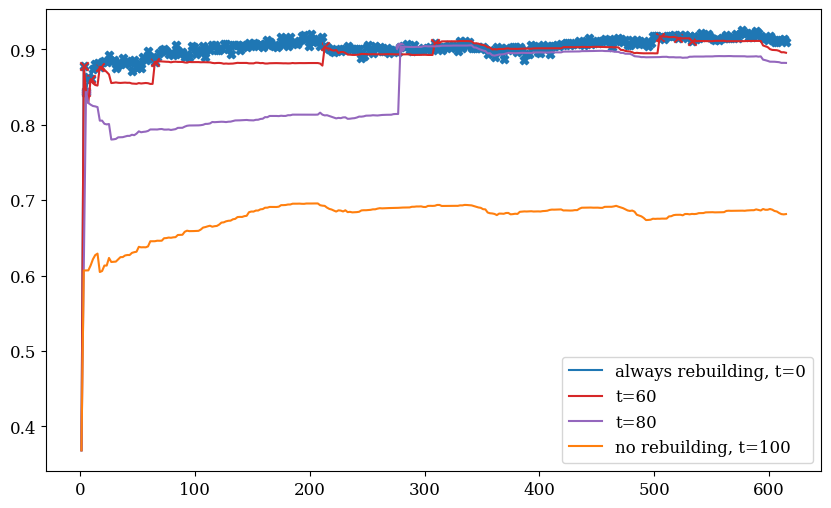

In [36]:
mode = "RecallTarget"
param = .9

# set size
plt.figure(figsize=(10, 6))
plt.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param)
                 ]["recall"],
    label="always rebuilding, t=0"
)
plt.scatter(msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["step"],
            msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["recall"],
            # label="t=0",
            marker="X", color="C0"
            )

# plt.plot(
#     msturing_shift_bf[(msturing_shift_bf["t"] == 40) &
#                   (msturing_shift_bf["param"] == param)
#                  ]["step"],
#     msturing_shift_bf[(msturing_shift_bf["t"] == 40) &
#                   (msturing_shift_bf["param"] == param)
#                  ]["recall"],
#     label="t=40"
# )

# plt.scatter(msturing_shift_bf[(msturing_shift_bf["t"] == 40) &
#                   (msturing_shift_bf["param"] == param) &
#                   (msturing_shift_bf["did_rebuild"] == True)
#                  ]["step"],
#             msturing_shift_bf[(msturing_shift_bf["t"] == 40) &
#                   (msturing_shift_bf["param"] == param) &
#                   (msturing_shift_bf["did_rebuild"] == True)
#                  ]["recall"],
#             # label="t=0",
#             marker="o", color="C1"
#             )

# plt.plot(
#     msturing_shift_bf[(msturing_shift_bf["t"] == 50) &
#                   (msturing_shift_bf["param"] == param)
#                  ]["step"],
#     msturing_shift_bf[(msturing_shift_bf["t"] == 50) &
#                   (msturing_shift_bf["param"] == param)
#                  ]["recall"],
#     label="t=50"
# )

plt.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 60) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 60) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode)
                 ]["recall"],
    label="t=60", color="C3"
)
plt.scatter(msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 60) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["step"],
            msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 60) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["recall"],
            # label="t=0",
            marker="x", color="C3"
            )

# plt.plot(
#     msturing_shift_bf[(msturing_shift_bf["t"] == 70) &
#                   (msturing_shift_bf["param"] == param)
#                  ]["step"],
#     msturing_shift_bf[(msturing_shift_bf["t"] == 70) &
#                   (msturing_shift_bf["param"] == param)
#                  ]["recall"],
#     label="t=70"
# )

# plt.scatter(msturing_shift_bf[(msturing_shift_bf["t"] == 70) &
#                   (msturing_shift_bf["param"] == param) &
#                   (msturing_shift_bf["did_rebuild"] == True)
#                  ]["step"],
#             msturing_shift_bf[(msturing_shift_bf["t"] == 70) &
#                   (msturing_shift_bf["param"] == param) &
#                   (msturing_shift_bf["did_rebuild"] == True)
#                  ]["recall"],
#             # label="t=0",
#             marker="o", color="C4"
#             )

plt.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 80) &
                  (msturing_shift_recalltarget["param"] == param) &
                    (msturing_shift_recalltarget['mode'] == mode)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 80) &
                  (msturing_shift_recalltarget["param"] == param) &
                    (msturing_shift_recalltarget['mode'] == mode)
                 ]["recall"],
    label="t=80", color="C4"
)

plt.scatter(msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 80) &
                  (msturing_shift_recalltarget["param"] == param) &
                    (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["step"],
            msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 80) &
                  (msturing_shift_recalltarget["param"] == param) &
                    (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["recall"],
            # label="t=0",
            marker="o", color="C4"
            )


plt.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 100) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 100) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode)
                 ]["recall"],
    label="no rebuilding, t=100",
)

plt.legend()

In [46]:
msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                #   (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param)]

,step,rebuild,mode,param,recall,activation,cof,query_time_s,phi,did_rebuild,active_step,t
5,1,threshold_0,RecallTarget,0.9,0.36828,0.29247,0.437259,0.016962,0.0000,False,1,0
15,3,threshold_0,RecallTarget,0.9,0.87787,0.47820,0.655347,0.019916,0.7479,True,3,0
25,5,threshold_0,RecallTarget,0.9,0.84361,0.45762,0.629924,0.020859,0.7444,True,5,0
35,7,threshold_0,RecallTarget,0.9,0.86314,0.44931,0.601984,0.021453,0.5743,True,7,0
45,9,threshold_0,RecallTarget,0.9,0.86069,0.46305,0.578344,0.021607,0.5103,True,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3035,607,threshold_0,RecallTarget,0.9,0.90939,0.46477,0.354564,0.021505,0.4644,True,607,0
3045,609,threshold_0,RecallTarget,0.9,0.91179,0.46892,0.273326,0.021799,0.4791,True,609,0
3055,611,threshold_0,RecallTarget,0.9,0.91298,0.47449,0.275261,0.021794,0.4494,True,611,0
3065,613,threshold_0,RecallTarget,0.9,0.91365,0.46994,0.259875,0.021687,0.5231,True,613,0


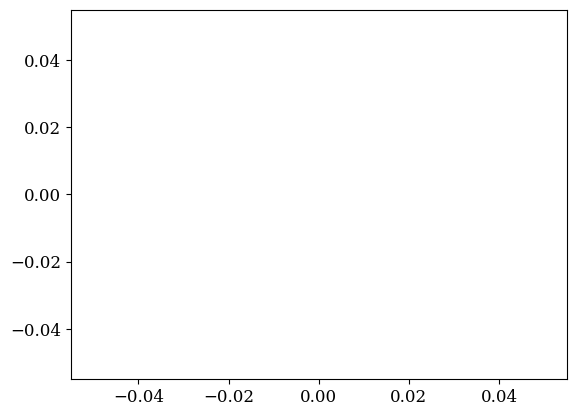

In [44]:
plt.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param)
                 ]["recall"],
    label="always rebuilding, t=0", color="C1"
)

Text(0.5, 0, 'Runbook Step')

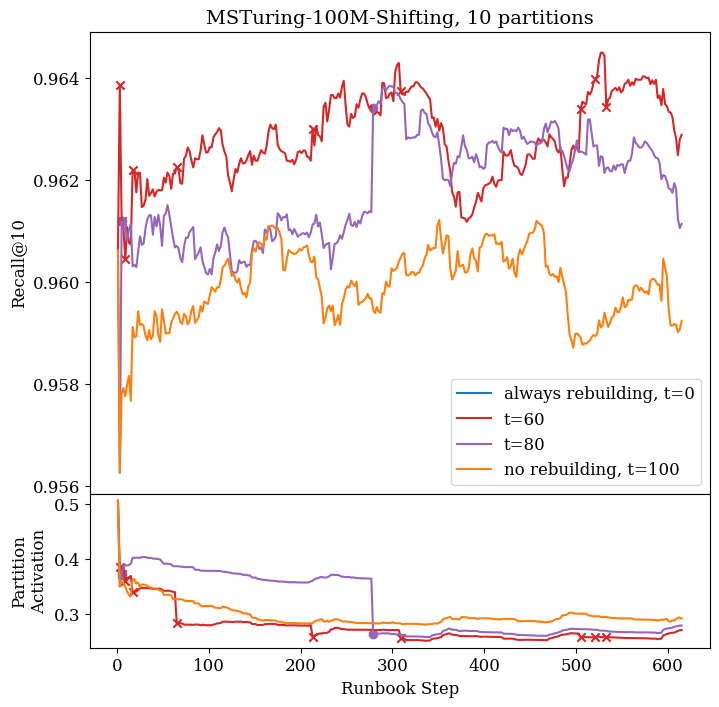

In [ ]:
mode = "Oracle"
param = .9

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

ax1.set_title("MSTuring-100M-Shifting, 10 partitions")
ax1.set_ylabel("Theoretical Recall@10")

ax1.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param)
                 ]["recall"],
    label="always rebuilding, t=0", color="C1"
)
ax1.scatter(msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["step"],
            msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["recall"],
            # label="t=0",
            marker="X", color="C0"
            )


ax1.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 60) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 60) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode)
                 ]["recall"],
    label="t=60", color="C3"
)
ax1.scatter(msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 60) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["step"],
            msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 60) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["recall"],
            # label="t=0",
            marker="x", color="C3"
            )

ax1.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 80) &
                  (msturing_shift_recalltarget["param"] == param) &
                    (msturing_shift_recalltarget['mode'] == mode)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 80) &
                  (msturing_shift_recalltarget["param"] == param) &
                    (msturing_shift_recalltarget['mode'] == mode)
                 ]["recall"],
    label="t=80", color="C4"
)

ax1.scatter(msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 80) &
                  (msturing_shift_recalltarget["param"] == param) &
                    (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["step"],
            msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 80) &
                  (msturing_shift_recalltarget["param"] == param) &
                    (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["recall"],
            # label="t=0",
            marker="o", color="C4"
            )


ax1.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 100) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 100) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode)
                 ]["recall"],
    label="no rebuilding, t=100",
)

ax1.legend()


ax2.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param)
                 ]["activation"],
    label="always rebuilding, t=0"
)
ax2.scatter(msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["step"],
            msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 0) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["activation"],
            # label="t=0",
            marker="X", color="C0"
            )


ax2.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 60) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 60) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode)
                 ]["activation"],
    label="t=60", color="C3"
)
ax2.scatter(msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 60) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["step"],
            msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 60) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["activation"],
            # label="t=0",
            marker="x", color="C3"
            )

ax2.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 80) &
                  (msturing_shift_recalltarget["param"] == param) &
                    (msturing_shift_recalltarget['mode'] == mode)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 80) &
                  (msturing_shift_recalltarget["param"] == param) &
                    (msturing_shift_recalltarget['mode'] == mode)
                 ]["activation"],
    label="t=80", color="C4"
)

ax2.scatter(msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 80) &
                  (msturing_shift_recalltarget["param"] == param) &
                    (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["step"],
            msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 80) &
                  (msturing_shift_recalltarget["param"] == param) &
                    (msturing_shift_recalltarget['mode'] == mode) &
                  (msturing_shift_recalltarget["did_rebuild"] == True)
                 ]["activation"],
            # label="t=0",
            marker="o", color="C4"
            )


ax2.plot(
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 100) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode)
                 ]["step"],
    msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 100) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == mode)
                 ]["activation"],
    label="no rebuilding, t=100",
)


ax2.set_ylabel("Partition\nActivation")
ax2.set_xlabel("Runbook Step")

In [43]:
msturing_shift_recalltarget[(msturing_shift_recalltarget["t"] == 100) &
                  (msturing_shift_recalltarget["param"] == param) &
                  (msturing_shift_recalltarget['mode'] == "RecallTarget")
                 ]

,step,rebuild,mode,param,recall,activation,cof,query_time_s,phi,did_rebuild,active_step,t
52365,1,threshold_1,RecallTarget,0.9,0.36828,0.29247,0.437259,0.016311,0.0000,False,1,100
52385,3,threshold_1,RecallTarget,0.9,0.60675,0.29247,0.437259,0.016174,0.7479,False,1,100
52405,5,threshold_1,RecallTarget,0.9,0.60675,0.29247,0.437259,0.016123,0.8160,False,1,100
52425,7,threshold_1,RecallTarget,0.9,0.60687,0.29247,0.437259,0.016493,0.8160,False,1,100
52445,9,threshold_1,RecallTarget,0.9,0.61339,0.29247,0.437259,0.016572,0.8127,False,1,100
...,...,...,...,...,...,...,...,...,...,...,...,...
58425,607,threshold_1,RecallTarget,0.9,0.68497,0.29247,0.437259,0.016834,0.8347,False,1,100
58445,609,threshold_1,RecallTarget,0.9,0.68300,0.29247,0.437259,0.016261,0.8169,False,1,100
58465,611,threshold_1,RecallTarget,0.9,0.68152,0.29247,0.437259,0.016198,0.8342,False,1,100
58485,613,threshold_1,RecallTarget,0.9,0.68114,0.29247,0.437259,0.017011,0.8391,False,1,100


In [58]:
df_test = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/cluster_history_msturing-100M-shift_10000_10/full_results_NProbe.csv")

In [67]:
df_test_t100 = pd.read_csv("/dataset/big-ann-benchmarks/data/MSTuring-100M-shift/cluster_history_msturing-100M-shift_10000_10/full_results_NProbe_t100.csv")

In [69]:
df_test_t100[
    (df_test_t100["param"] == 3)
]

,step,rebuild,mode,param,recall,activation,cof,query_time_s,phi,did_rebuild,active_step
2,1,threshold_1,NProbe,3,0.51071,0.3,0.437816,0.711387,0.0000,False,1
11,3,threshold_1,NProbe,3,0.28721,0.3,0.437816,0.699504,0.7479,False,1
20,5,threshold_1,NProbe,3,0.28783,0.3,0.437816,0.699850,0.8160,False,1
29,7,threshold_1,NProbe,3,0.28352,0.3,0.437816,0.700250,0.8160,False,1
38,9,threshold_1,NProbe,3,0.27871,0.3,0.437816,0.699750,0.8127,False,1
...,...,...,...,...,...,...,...,...,...,...,...
2729,607,threshold_1,NProbe,3,0.28532,0.3,0.437816,0.699491,0.8347,False,1
2738,609,threshold_1,NProbe,3,0.28787,0.3,0.437816,0.700073,0.8169,False,1
2747,611,threshold_1,NProbe,3,0.28954,0.3,0.437816,0.700674,0.8342,False,1
2756,613,threshold_1,NProbe,3,0.29033,0.3,0.437816,0.699543,0.8391,False,1


Text(0, 0.5, 'Theoretical Recall@10')

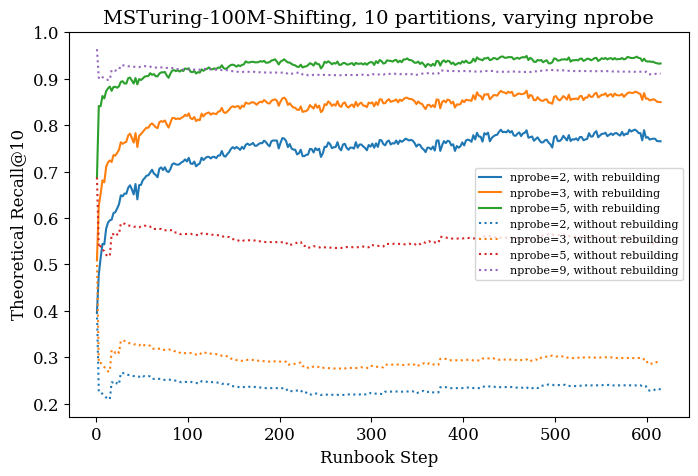

In [85]:
# param = 2
# fig.set_size_inches(8, 5)

# set figsize
plt.figure(figsize=(8, 5))

plt.plot(df_test[(df_test["rebuild"]=="rebuild") &
        (df_test["param"]==2)
        ]["step"],
    df_test[(df_test["rebuild"]=="rebuild") &
            (df_test["param"]==2)
            ]["recall"],
    label="nprobe=2, with rebuilding"
)

plt.plot(df_test[(df_test["rebuild"]=="rebuild") &
        (df_test["param"]==3)
        ]["step"],
    df_test[(df_test["rebuild"]=="rebuild") &
            (df_test["param"]==3)
            ]["recall"],
    label="nprobe=3, with rebuilding"
)

# plt.plot(df_test[(df_test["rebuild"]=="rebuild") &
#         (df_test["param"]==4)
#         ]["step"],
#     df_test[(df_test["rebuild"]=="rebuild") &
#             (df_test["param"]==4)
#             ]["recall"],
#     label="nprobe=4, with rebuilding"
# )
plt.plot(df_test[(df_test["rebuild"]=="rebuild") &
        (df_test["param"]==5)
        ]["step"],
    df_test[(df_test["rebuild"]=="rebuild") &
            (df_test["param"]==5)
            ]["recall"],
    label="nprobe=5, with rebuilding"
)

# param = 2
plt.plot(df_test[(df_test["rebuild"]=="no_rebuild") &
        (df_test["param"]==2)
        ]["step"],
    df_test[(df_test["rebuild"]=="no_rebuild") &
            (df_test["param"]==2)
            ]["recall"],
    label="nprobe=2, without rebuilding", ls=":", color="C0"
)

# plt.plot(df_test_t100[
#     (df_test_t100["param"] == 2)
#         ]["step"],
#         df_test_t100[
#     (df_test_t100["param"] == 2)
# ]["recall"],
#     label="2, t=100", ls="--", color="C0")


plt.plot(df_test[(df_test["rebuild"]=="no_rebuild") &
        (df_test["param"]==3)
        ]["step"],
    df_test[(df_test["rebuild"]=="no_rebuild") &
            (df_test["param"]==3)
            ]["recall"],
    label="nprobe=3, without rebuilding", ls=":", color="C1"
)

# plt.plot(df_test[(df_test["rebuild"]=="no_rebuild") &
#         (df_test["param"]==4)
#         ]["step"],
#     df_test[(df_test["rebuild"]=="no_rebuild") &
#             (df_test["param"]==4)
#             ]["recall"],
#     label="nprobe=4, without rebuilding", ls=":", color="C2"
# )
# plt.plot(df_test_t100[
#     (df_test_t100["param"] == 4)
#         ]["step"],
#         df_test_t100[
#     (df_test_t100["param"] == 4)
# ]["recall"],
#     label="4, t=100", ls="--", color="C2")

plt.plot(df_test[(df_test["rebuild"]=="no_rebuild") &
        (df_test["param"]==5)
        ]["step"],
    df_test[(df_test["rebuild"]=="no_rebuild") &
            (df_test["param"]==5)
            ]["recall"],
    label="nprobe=5, without rebuilding", ls=":", color="C3"
)

plt.plot(df_test[(df_test["rebuild"]=="no_rebuild") &
        (df_test["param"]==9)
        ]["step"],
    df_test[(df_test["rebuild"]=="no_rebuild") &
            (df_test["param"]==9)
            ]["recall"],
    label="nprobe=9, without rebuilding", ls=":", color="C4"
)

plt.legend(fontsize=8)
plt.title("MSTuring-100M-Shifting, 10 partitions, varying nprobe")
plt.xlabel("Runbook Step")
plt.ylabel("Theoretical Recall@10")


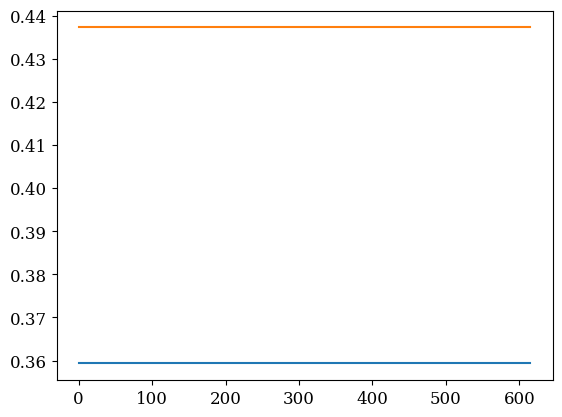

In [94]:
plt.plot(df_test[(df_test["rebuild"]=="no_rebuild") &
        (df_test["param"]==5)
        ]["step"],
    df_test[(df_test["rebuild"]=="no_rebuild") &
            (df_test["param"]==5)
            ]["cof"],
)

plt.plot(msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "RecallTarget") &
                  (msturing_shift["param"] == param)
                 ]['step'], msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "RecallTarget") &
                  (msturing_shift["param"] == param)
                 ]['cof'])


In [ ]:
msturing_shift[(msturing_shift["t"] == 100) &
                  (msturing_shift["mode"] == "RecallTarget") &
                  (msturing_shift["param"] == param)
                 ]['cof']

,step,rebuild,mode,param,recall,activation,cof,query_time_s,phi,did_rebuild,active_step,t
55445,1,threshold_1,RecallTarget,0.9,0.36828,0.29247,0.437259,0.016311,0.0000,False,1,100
55465,3,threshold_1,RecallTarget,0.9,0.60675,0.29247,0.437259,0.016174,0.7479,False,1,100
55485,5,threshold_1,RecallTarget,0.9,0.60675,0.29247,0.437259,0.016123,0.8160,False,1,100
55505,7,threshold_1,RecallTarget,0.9,0.60687,0.29247,0.437259,0.016493,0.8160,False,1,100
55525,9,threshold_1,RecallTarget,0.9,0.61339,0.29247,0.437259,0.016572,0.8127,False,1,100
...,...,...,...,...,...,...,...,...,...,...,...,...
61505,607,threshold_1,RecallTarget,0.9,0.68497,0.29247,0.437259,0.016834,0.8347,False,1,100
61525,609,threshold_1,RecallTarget,0.9,0.68300,0.29247,0.437259,0.016261,0.8169,False,1,100
61545,611,threshold_1,RecallTarget,0.9,0.68152,0.29247,0.437259,0.016198,0.8342,False,1,100
61565,613,threshold_1,RecallTarget,0.9,0.68114,0.29247,0.437259,0.017011,0.8391,False,1,100
